In [6]:
import pandas as pd
import numpy as np

# 1. Load the credit dataset 
df = pd.read_csv(r"C:\Users\amest\Downloads\Credit_Risk_Project\german_credit_data.csv")

# 2. View the first 5 rows to see what data the bank tracked
print("--- FIRST 5 ROWS ---")
display(df.head())

# 3. Check for missing values (e.g., null income records)
print("\n--- MISSING VALUE SUMMARY ---")
print(df.isnull().sum())

--- FIRST 5 ROWS ---


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad



--- MISSING VALUE SUMMARY ---
status_account             0
month_duration             0
credit_history             0
purpose                    0
credit_amount              0
status_savings             0
years_employment           0
payment_to_income_ratio    0
status_and_sex             0
secondary_obligor          0
residence_since            0
collateral                 0
age                        0
other_installment_plans    0
housing                    0
n_credits                  0
job                        0
n_guarantors               0
telephone                  0
is_foreign_worker          0
target                     0
dtype: int64


In [7]:
# 1. Isolate the target variable (what we want to predict)
y = df['target']

# 2. Isolate the feature variables (drop the target column from X)
# We also drop unneeded index columns if your Kaggle dataset came with an 'Unnamed: 0' row
X = df.drop(columns=['target'])

if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (1000, 20)
Target (y) shape: (1000,)


In [8]:
# Automatically detect text columns and convert them into 0 and 1 columns
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original features columns count:", X.shape[1])
print("Encoded numeric features columns count:", X_encoded.shape[1])
print("\nFirst 3 rows of your new numeric-only data matrix:")
display(X_encoded.head(3))

Original features columns count: 20
Encoded numeric features columns count: 48

First 3 rows of your new numeric-only data matrix:


,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,status_account_< 0 DM,status_account_>= 200 DM,status_account_no checking account,...,collateral_savings agreement/life insurance,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes
0,6,1169,4,4,67,2,1,True,False,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,False,False,False,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,False,False,True,...,False,True,False,True,False,False,False,True,False,True


In [9]:
from sklearn.model_selection import train_test_split

# Split into 80% Training data and 20% Testing data
# random_state ensures your splits remain identical every time you rerun the cell
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

print("Training Features Matrix Shape:", X_train.shape)
print("Testing Features Matrix Shape:", X_test.shape)
print("Training Target Labels Shape:", y_train.shape)
print("Testing Target Labels Shape:", y_test.shape)

Training Features Matrix Shape: (800, 48)
Testing Features Matrix Shape: (200, 48)
Training Target Labels Shape: (800,)
Testing Target Labels Shape: (200,)


In [10]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# class_weight='balanced' helps the model deal with imbalanced banking datasets
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Train the model using the training subsets
rf_model.fit(X_train, y_train)

# 3. Generate predictions on the hidden test set
y_pred = rf_model.predict(X_test)

print("Random Forest Classifier successfully trained on credit data metrics!")

Random Forest Classifier successfully trained on credit data metrics!


--- CREDIT RISK MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

         bad       0.69      0.34      0.45        59
        good       0.77      0.94      0.85       141

    accuracy                           0.76       200
   macro avg       0.73      0.64      0.65       200
weighted avg       0.75      0.76      0.73       200



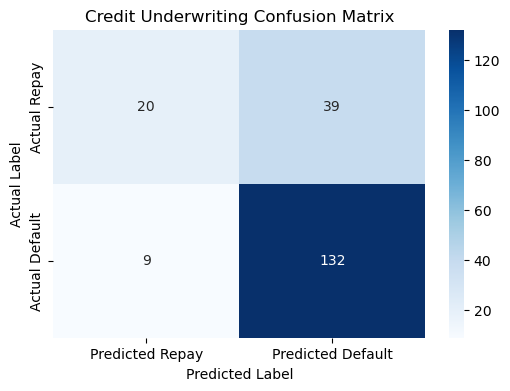

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Print the complete classification performance breakdown
print("--- CREDIT RISK MODEL PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred))

# 2. Compute the Confusion Matrix matrix array
cm = confusion_matrix(y_test, y_pred)

# 3. Plot a clean heatmap to visualize True vs Predicted values
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Repay', 'Predicted Default'],
            yticklabels=['Actual Repay', 'Actual Default'])
plt.title('Credit Underwriting Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [12]:
# Train an optimized model to catch more defaulters
rf_optimized = RandomForestClassifier(
    n_estimators=200, 
    max_depth=6,
    criterion='entropy',
    class_weight='balanced', 
    random_state=42
)

rf_optimized.fit(X_train, y_train)
y_pred_opt = rf_optimized.predict(X_test)

# Print the new performance breakdown
print("--- OPTIMIZED CREDIT RISK MODEL PERFORMANCE ---")
print(classification_report(y_test, y_pred_opt))

--- OPTIMIZED CREDIT RISK MODEL PERFORMANCE ---
              precision    recall  f1-score   support

         bad       0.58      0.69      0.63        59
        good       0.86      0.79      0.82       141

    accuracy                           0.76       200
   macro avg       0.72      0.74      0.73       200
weighted avg       0.78      0.76      0.77       200

